### 1. 数据检查

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("financial_loan.csv")

In [42]:
df.shape
df.head()
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  str    
 2   emp_length             38576 non-null  str    
 3   emp_title              37138 non-null  str    
 4   grade                  38576 non-null  str    
 5   home_ownership         38576 non-null  str    
 6   issue_date             38576 non-null  str    
 7   last_credit_pull_date  38576 non-null  str    
 8   last_payment_date      38576 non-null  str    
 9   loan_status            38576 non-null  str    
 10  next_payment_date      38576 non-null  str    
 11  member_id              38576 non-null  int64  
 12  purpose                38576 non-null  str    
 13  sub_grade              38576 non-null  str    
 14  term                   38576 non-null  str    
 15  verification_

np.int64(0)

原数据表中的时间格式为“日-月-年”，使用`pandas`中的`to_datetime`将其调整为“年-月-日”。其中`%d`代表日，`%m`代表月，`y`代表两位数年份，例如21年，`Y`代表四位数年份，例如2021年。

In [46]:
df['issue_date'] = pd.to_datetime(df['issue_date'], format='%d-%m-%Y')
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'], format='%d-%m-%Y')
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], format='%d-%m-%Y')
df.head()

,id,address_state,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,Charged Off,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,Fully Paid,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,Charged Off,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,Fully Paid,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,Fully Paid,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


### 2. 探究影响坏账的因素

查看贷款结果的三种状态，包括已全部收回、暂未收回、坏帐核销。

In [47]:
df['loan_status'].value_counts()

loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64

为了探究借贷回收的影响因素，在此构建二分变量。新建一列 `bad_loan`，将坏账登记为1，已回收的账目登记为0，由于当下的 “Current” 状态无法保证以后的借贷回收情况，在此不作考虑。

In [51]:
analysis_df = df[df['loan_status'].isin(["Fully Paid", "Charged Off"])].copy()

In [53]:
analysis_df['bad_loan'] = analysis_df['loan_status'].map({
    "Fully Paid": 0, "Charged Off": 1
})

#### 2.1 分类变量

In [63]:
# 房屋情况
analysis_df.groupby("home_ownership")["bad_loan"].mean()

# 贷款用途
analysis_df.groupby("purpose")["bad_loan"].mean()

# 贷款期限
analysis_df.groupby("term")["bad_loan"].mean()

# 收入认证情况
analysis_df.groupby("verification_status")["bad_loan"].mean()

home_ownership
MORTGAGE    0.134552
NONE        0.000000
OTHER       0.183673
OWN         0.143477
RENT        0.149038
Name: bad_loan, dtype: float64

由以上结果可以看到，坏账在房屋租赁等长时间项目中出现的概率更高，即使有收入认证，也存在着坏账风险。

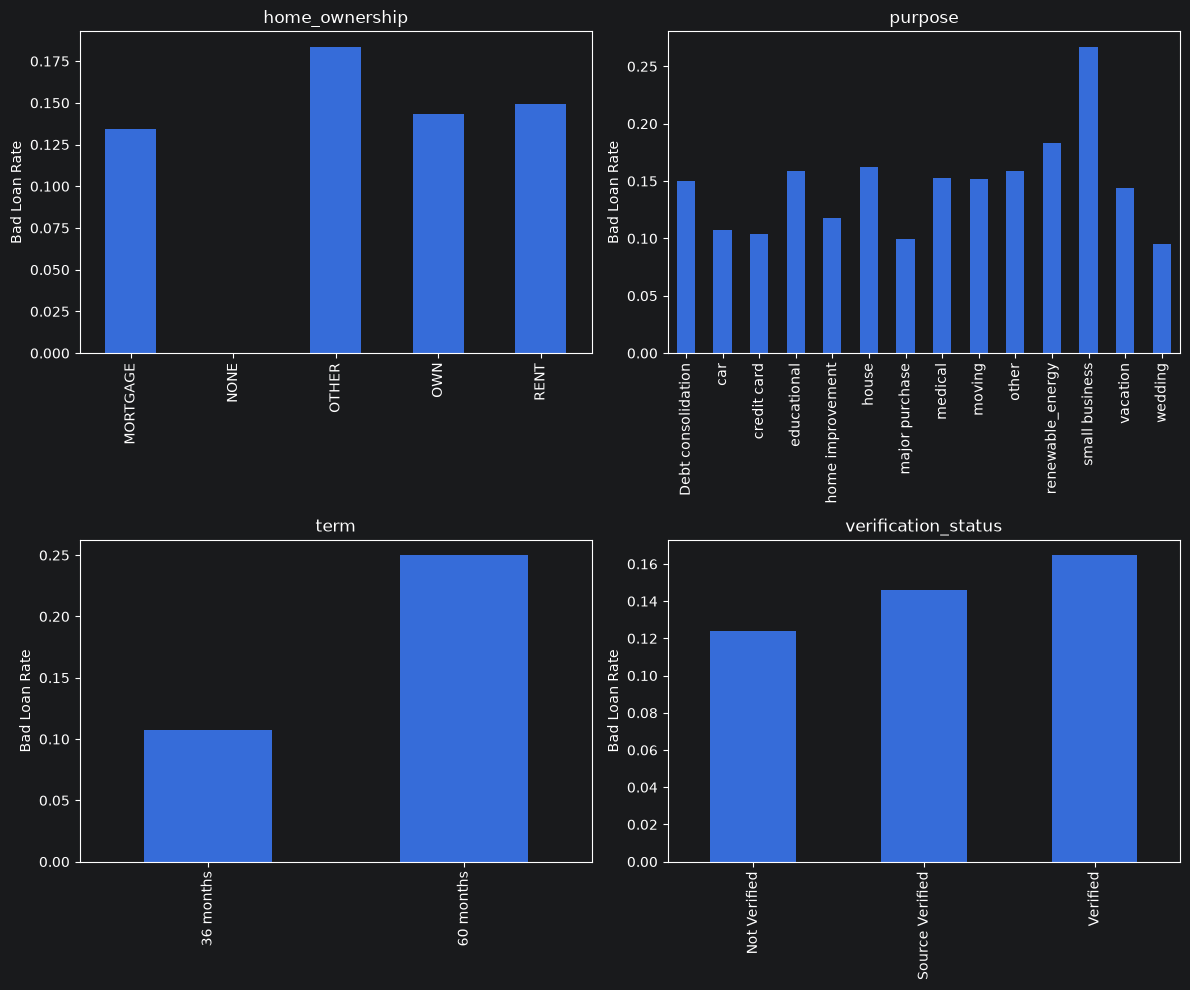

In [116]:
variables = ['home_ownership', 'purpose', 'term', 'verification_status']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for var, ax in zip(variables, axes.flatten()):
    bad_rate = analysis_df.groupby(var)['bad_loan'].mean()
    bad_rate.plot(
        kind='bar',
        ax=ax
    )
    ax.set_title(var)
    ax.set_ylabel('Bad Loan Rate')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

#### 2.2 连续变量

In [114]:
analysis_df.groupby('bad_loan')[
    ['annual_income', 'dti', 'loan_amount', 'int_rate', 'installment', 'total_acc']
].mean()

,annual_income,dti,loan_amount,int_rate,installment,total_acc
bad_loan,,,,,,
0,70427.586885,0.131674,10930.419972,0.116411,322.093131,22.181117
1,63515.728245,0.140047,12288.060191,0.138786,340.778076,21.572661


In [69]:
analysis_df.groupby('bad_loan')[
    ['annual_income', 'dti', 'loan_amount', 'int_rate', 'installment', 'total_acc']
].median()

,annual_income,dti,loan_amount,int_rate,installment,total_acc
bad_loan,,,,,,
0,60000.0,0.1321,9600.0,0.1149,277.70,21.0
1,54000.0,0.1432,10000.0,0.1361,298.67,20.0


In [67]:
analysis_df.groupby('bad_loan')['dti'].describe()

,count,mean,std,min,25%,50%,75%,max
bad_loan,,,,,,,,
0,32145.0,0.131674,0.066684,0.0,0.0802,0.1321,0.1840,0.2999
1,5333.0,0.140047,0.065623,0.0,0.0912,0.1432,0.1927,0.2985


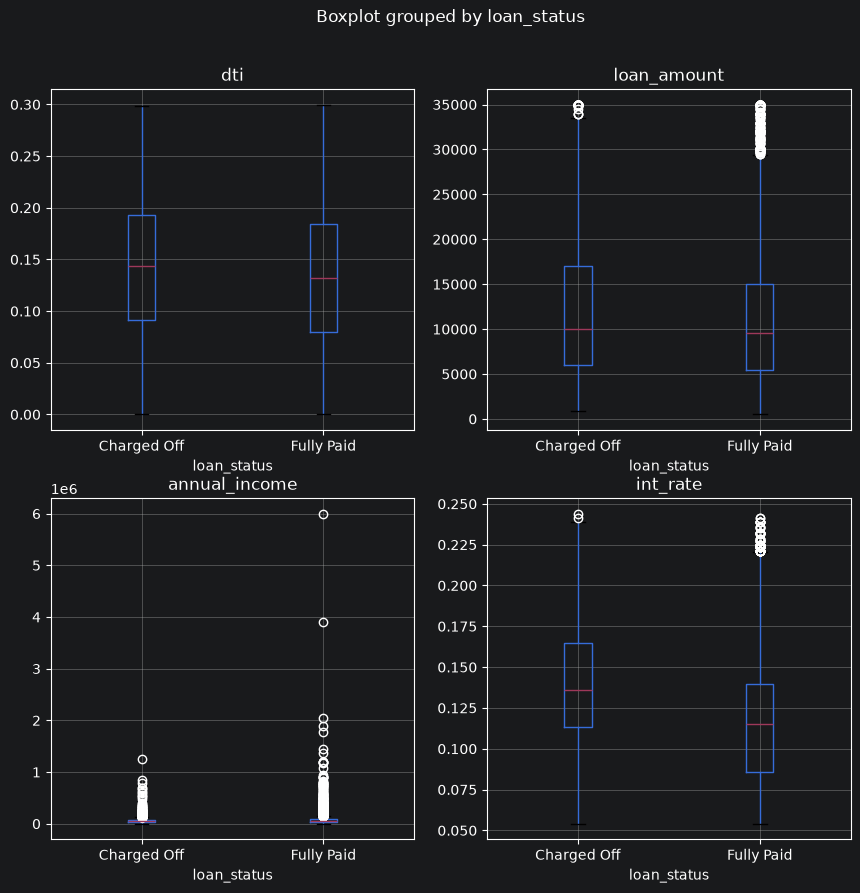

In [83]:
variables = ['dti', 'loan_amount', 'annual_income', 'int_rate']
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for var, ax in zip(variables, axes.flatten()):
    analysis_df.boxplot(
        column=var,
        by = 'loan_status',
        ax = ax
    )
plt.show()

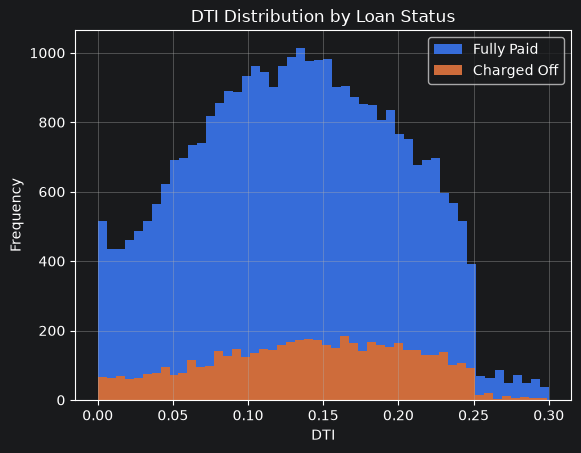

In [103]:
analysis_df[
    analysis_df['loan_status'] == 'Fully Paid'
]['dti'].hist(bins=50, label='Fully Paid')

analysis_df[
    analysis_df['loan_status'] == 'Charged Off'
]['dti'].hist(bins=50, label = 'Charged Off')

plt.xlabel('DTI')
plt.ylabel('Frequency')
plt.title('DTI Distribution by Loan Status')
plt.legend()
plt.show()

### 3. 回归分析

In [179]:
features = ['dti','annual_income','loan_amount','int_rate','total_acc','term','home_ownership','verification_status','grade','sub_grade','emp_length','purpose']
model_df = analysis_df[features + ['bad_loan']]

周期、房屋拥有情况、收入证明状态、信用评级等变量属于无序分类变量，在回归分析中需要调整它们的输入方式。这里用到`pandas`中的`get_dummies`函数，将其转换为“dummy variable”。特别注意的是，模型中的类别数为实际存在的类别数减1，在这里体现为`drop_first=True`。

In [180]:
model_df = pd.get_dummies(
    model_df,
    columns=['term', 'home_ownership', 'verification_status','grade','sub_grade','emp_length','purpose'],
    drop_first=True
)

In [181]:
x = model_df.drop(columns='bad_loan')
y = model_df['bad_loan']

使用`sklearn`中的包划分训练集和测试集，训练集的比例为总数的80%。此外，坏账在总样本数中只占一小部分，为了使训练集和测试集中好坏账的比例和原数据集一致，这里使用`stratify=y`意为保证相应变量中各类别的比例不变。

In [182]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

由于连续变量中不同类别的数据存在较大差异，直接带入模型存在问题，在此先进行标准化。对于训练集使用的是`fit_transform`,使用样本数据学习均值和标准差进行标准化。对于测试集，为了防止数据泄露，直接使用训练集得到的均值和方差。

In [192]:
numeric_features = ['dti','annual_income','loan_amount','int_rate','total_acc']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train[numeric_features] = scaler.fit_transform(
    x_train[numeric_features]
)

x_test[numeric_features] = scaler.transform(
    x_test[numeric_features]
)

In [193]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [194]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92      6429
           1       0.61      0.02      0.05      1067

    accuracy                           0.86      7496
   macro avg       0.73      0.51      0.48      7496
weighted avg       0.82      0.86      0.80      7496



              precision    recall  f1-score   support

           0       0.86      1.00      0.92      6429
           1       0.61      0.02      0.05      1067

    accuracy                           0.86      7496
   macro avg       0.73      0.51      0.48      7496
weighted avg       0.82      0.86      0.80      7496



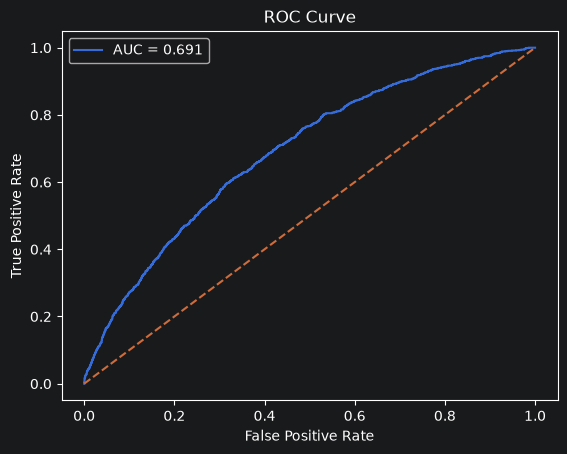

AUC: 0.6905263068893397


In [197]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model.fit(x_train, y_train)
print(classification_report(y_test, y_pred))
y_prob = model.predict_proba(x_test)[:, 1]

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

print("AUC:", auc)